Access with dataset

## Dataset Structure

Dataset gồm 7,043 quan sát và 33 thuộc tính.

Các thuộc tính được phân thành các nhóm chính:

1. **Identifier:** thông tin định danh bản ghi/khách hàng.
2. **Geographic:** thông tin vị trí địa lý của khách hàng.
3. **Demographic:** đặc điểm nhân khẩu học.
4. **Customer Relationship:** thời gian gắn bó với doanh nghiệp.
5. **Services:** các dịch vụ khách hàng đang sử dụng.
6. **Contract & Billing:** hợp đồng, phương thức thanh toán và chi phí.
7. **Churn/Outcome:** thông tin liên quan đến trạng thái churn.

Biến mục tiêu dự kiến của bài toán phân loại là `Churn Value`,
trong đó 0 biểu thị khách hàng không churn và 1 biểu thị khách hàng churn.

Một số thuộc tính như `CustomerID`, `Country`, `State` có thể không mang
nhiều thông tin dự đoán, trong khi `Churn Label`, `Churn Score` và
`Churn Reason` cần được xem xét nguy cơ data leakage trước khi xây dựng mô hình.2

In [58]:
import pandas as pd

df = pd.read_excel("../data/raw/customerChurn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


How big of dataset

In [59]:
df.shape

(7043, 33)

Xem chinh xac 33 thuoc tinh

In [60]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

kiem tra du lieu

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [62]:
df.shape
df.columns.tolist()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [63]:
for i, col in enumerate(df.columns):
    print(i, col, "-", df[col].dtype)

0 CustomerID - object
1 Count - int64
2 Country - object
3 State - object
4 City - object
5 Zip Code - int64
6 Lat Long - object
7 Latitude - float64
8 Longitude - float64
9 Gender - object
10 Senior Citizen - object
11 Partner - object
12 Dependents - object
13 Tenure Months - int64
14 Phone Service - object
15 Multiple Lines - object
16 Internet Service - object
17 Online Security - object
18 Online Backup - object
19 Device Protection - object
20 Tech Support - object
21 Streaming TV - object
22 Streaming Movies - object
23 Contract - object
24 Paperless Billing - object
25 Payment Method - object
26 Monthly Charges - float64
27 Total Charges - object
28 Churn Label - object
29 Churn Value - int64
30 Churn Score - int64
31 CLTV - int64
32 Churn Reason - object


In [64]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- CustomerID ---
CustomerID
3668-QPYBK    1
9169-BSVIN    1
0206-OYVOC    1
6418-HNFED    1
8805-JNRAZ    1
8439-LTUGF    1
1767-TGTKO    1
1194-HVAIF    1
1080-BWSYE    1
8387-UGUSU    1
Name: count, dtype: int64

--- Country ---
Country
United States    7043
Name: count, dtype: int64

--- State ---
State
California    7043
Name: count, dtype: int64

--- City ---
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Bakersfield       40
Name: count, dtype: int64

--- Lat Long ---
Lat Long
33.964131, -118.272783    5
34.152875, -118.486056    5
32.912664, -116.635387    5
32.64164, -116.985026     5
32.607964, -117.059459    5
34.105493, -117.660934    5
34.141146, -117.655583    5
34.101608, -118.055848    5
33.992416, -117.807874    5
34.231318, -117.662032    5
Name: count, dtype: int64

--- Gender ---
Gender
Male      3555
Female    3488
Nam

In [65]:

df["Churn Value"].value_counts()
df["Churn Value"].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [66]:
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

 1. CustomerID
 2. Count
 3. Country
 4. State
 5. City
 6. Zip Code
 7. Lat Long
 8. Latitude
 9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


In [67]:
df["Tenure Months"].value_counts()

Tenure Months
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

In [68]:
df["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [69]:
df[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]].describe()

,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755
std,24.559481,30.090047,1183.057152
min,0.000000,18.250000,2003.000000
25%,9.000000,35.500000,3469.000000
50%,29.000000,70.350000,4527.000000
75%,55.000000,89.850000,5380.500000
max,72.000000,118.750000,6500.000000


Toàn bộ danh sách cột trước khi phân loại

In [70]:
for i, col in enumerate(df.columns):
    print(i, col, "-", df[col].dtype)

0 CustomerID - object
1 Count - int64
2 Country - object
3 State - object
4 City - object
5 Zip Code - int64
6 Lat Long - object
7 Latitude - float64
8 Longitude - float64
9 Gender - object
10 Senior Citizen - object
11 Partner - object
12 Dependents - object
13 Tenure Months - int64
14 Phone Service - object
15 Multiple Lines - object
16 Internet Service - object
17 Online Security - object
18 Online Backup - object
19 Device Protection - object
20 Tech Support - object
21 Streaming TV - object
22 Streaming Movies - object
23 Contract - object
24 Paperless Billing - object
25 Payment Method - object
26 Monthly Charges - float64
27 Total Charges - object
28 Churn Label - object
29 Churn Value - int64
30 Churn Score - int64
31 CLTV - int64
32 Churn Reason - object


Tách theo dtype để tham khảo

In [71]:
numerical_cols_raw = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_raw = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical by dtype:")
print(numerical_cols_raw)

print("\nCategorical by dtype:")
print(categorical_cols_raw)

Numerical by dtype:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

Categorical by dtype:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


Xác định target

In [72]:
target_col = "Churn Value"

In [73]:
id_cols = [
    "CustomerID"
]

In [74]:
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [75]:
categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [76]:
special_cols = [
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

In [77]:
feature_dict = pd.DataFrame({
    "Feature": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Unique Values": df.nunique(dropna=False).values
})

feature_dict



,Feature,Dtype,Unique Values
0,CustomerID,object,7043
1,Count,int64,1
2,Country,object,1
3,State,object,1
4,City,object,1129
5,Zip Code,int64,1652
6,Lat Long,object,1652
7,Latitude,float64,1652
8,Longitude,float64,1651
9,Gender,object,2


In [78]:
def get_role(col):
    if col == target_col:
        return "Target"
    elif col in id_cols:
        return "Identifier"
    elif col in numerical_features:
        return "Numerical Feature"
    elif col in categorical_features:
        return "Categorical Feature"
    elif col in special_cols:
        return "Needs Review"
    else:
        return "Unclassified"

feature_dict["Role"] = feature_dict["Feature"].apply(get_role)

feature_dict

,Feature,Dtype,Unique Values,Role
0,CustomerID,object,7043,Identifier
1,Count,int64,1,Needs Review
2,Country,object,1,Needs Review
3,State,object,1,Needs Review
4,City,object,1129,Needs Review
5,Zip Code,int64,1652,Needs Review
6,Lat Long,object,1652,Needs Review
7,Latitude,float64,1652,Needs Review
8,Longitude,float64,1651,Needs Review
9,Gender,object,2,Categorical Feature


In [79]:
feature_dict[feature_dict["Role"] == "Unclassified"]

,Feature,Dtype,Unique Values,Role


### Nhận xét

Dataset gồm nhiều nhóm thuộc tính khác nhau:

- Biến định danh: dùng để nhận diện khách hàng.
- Biến số: các đại lượng như thời gian sử dụng và chi phí.
- Biến phân loại: các thông tin về nhân khẩu học, dịch vụ, hợp đồng và thanh toán.
- Biến mục tiêu: `Churn Value`.
- Một số biến cần xem xét riêng do có thể là biến hằng, biến địa lý hoặc có nguy cơ gây data leakage.

Việc phân loại biến giúp xác định chiến lược preprocessing phù hợp cho từng nhóm, chẳng hạn encoding cho biến categorical, scaling cho một số biến numerical, loại bỏ identifier và kiểm tra các biến có nguy cơ leakage.

## T008 — Descriptive Statistics
### 1. Numerical Features

mean   → số tháng sử dụng trung bình
std    → mức độ phân tán
min    → khách hàng mới nhất
25%    → 25% khách hàng có tenure ≤ giá trị này
50%    → median
75%    → 75% khách hàng có tenure ≤ giá trị này
max    → khách hàng lâu năm nhất

mean = 32
50%  = 29
max  = 72

Khách hàng sử dụng dịch vụ trung bình khoảng 32 tháng, median khoảng 29 tháng và thời gian sử dụng tối đa là 72 tháng.

In [82]:
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.0,4527.00,5380.50,6500.00


Thời gian sử dụng dịch vụ giao động từ 0 đến 72 tháng. trung bình 32 tháng và median 29 tháng 

In [84]:
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

Phần lớn khách hàng sử dụng hợp đồng hàng tháng 

In [85]:
categorical_to_check = [
    "Gender",
    "Senior Citizen",
    "Internet Service",
    "Contract",
    "Payment Method"
]

for col in categorical_to_check:
    print(f"\n===== {col} =====")
    print((df[col].value_counts(normalize=True) * 100).round(2))


===== Gender =====
Gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64

===== Senior Citizen =====
Senior Citizen
No     83.79
Yes    16.21
Name: proportion, dtype: float64

===== Internet Service =====
Internet Service
Fiber optic    43.96
DSL            34.37
No             21.67
Name: proportion, dtype: float64

===== Contract =====
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64

===== Payment Method =====
Payment Method
Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: proportion, dtype: float64


Tỉ lệ nam nữ ngang nhau, Đa phần là người trẻ, fiber optic được sử dụng nhiều trong internet service, hợp đồng theo tháng có vẻ chiếm nhiều, 

In [86]:
df["Churn Value"].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Có 26,5% khách hàng đã churn 

## T009 —  missing values

In [88]:
null_count = df.isnull().sum()

null_count[null_count > 0]

Churn Reason    5174
dtype: int64

In [89]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_report[missing_report["Missing Count"] > 0]

,Missing Count,Missing Percent
Churn Reason,5174,73.46


In [90]:
pd.crosstab(
    df["Churn Value"],
    df["Churn Reason"].isnull(),
    margins=True
)

Churn Reason,False,True,All
Churn Value,,,
0,0,5174,5174
1,1869,0,1869
All,1869,5174,7043


In [101]:
object_cols = df.select_dtypes(include="object").columns

blank_count = (
    df[object_cols]
    .apply(lambda col: col.astype(str).str.strip().eq("").sum())
)

blank_count[blank_count > 0]

Total Charges    11
dtype: int64

In [102]:
print("Missing Total Charges:")
print(df["Total Charges"].isna().sum())

print("\nBlank Total Charges:")
print(df["Total Charges"].astype(str).str.strip().eq("").sum())

print("\nData type:")
print(df["Total Charges"].dtype)

Missing Total Charges:
0

Blank Total Charges:
11

Data type:
object


In [103]:
blank_total_charges = df["Total Charges"].astype(str).str.strip().eq("")

df.loc[
    blank_total_charges,
    [
        "CustomerID",
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "Contract",
        "Churn Value"
    ]
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Contract,Churn Value
2234,4472-LVYGI,0,52.55,,Two year,0
2438,3115-CZMZD,0,20.25,,Two year,0
2568,5709-LVOEQ,0,80.85,,Two year,0
2667,4367-NUYAO,0,25.75,,Two year,0
2856,1371-DWPAZ,0,56.05,,Two year,0
4331,7644-OMVMY,0,19.85,,Two year,0
4687,3213-VVOLG,0,25.35,,Two year,0
5104,2520-SGTTA,0,20.00,,Two year,0
5719,2923-ARZLG,0,19.70,,One year,0
6772,4075-WKNIU,0,73.35,,Two year,0


### Missing Value Findings

Qua kiểm tra dữ liệu thiếu:

- `Total Charges` không chứa giá trị NaN nhưng có 11 giá trị blank.
- 11/7,043 bản ghi bị ảnh hưởng, tương đương khoảng 0.16% dataset.
- Cả 11 khách hàng đều có `Tenure Months = 0`.
- Do đó, các giá trị thiếu không xuất hiện ngẫu nhiên mà tập trung ở nhóm
  khách hàng có thời gian sử dụng bằng 0 tháng.
- Đề xuất ở bước Data Cleaning: chuyển các giá trị blank của `Total Charges`
  thành 0 và chuyển kiểu dữ liệu của cột từ `object` sang kiểu số.
- Dataset raw được giữ nguyên; việc xử lý sẽ được thực hiện ở giai đoạn
  Data Preparation.

## T010 — Duplicate Analysis

In [106]:
duplicate_rows = df.duplicated().sum()
print(f"duplicate: {duplicate_rows}")

duplicate: 0


In [107]:
print("Total rows:", len(df))
print("Unique CustomerID:", df["CustomerID"].nunique())
print("Duplicated CustomerID:", df["CustomerID"].duplicated().sum())

Total rows: 7043
Unique CustomerID: 7043
Duplicated CustomerID: 0


In [108]:
duplicate_customer_ids = df[
    df["CustomerID"].duplicated(keep=False)
].sort_values("CustomerID")

duplicate_customer_ids

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


### Duplicate Analysis Findings

- Dataset contains 7,043 records.
- No fully duplicated records were detected.
- `CustomerID` was also checked separately because it uniquely identifies
  each customer.
- No duplicated `CustomerID` values were detected.

Therefore, no duplicate-related data quality issue was identified at this stage.

## T011 — Outlier Analysis

In [ ]:
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]


df[numerical_features].describe().T[
  ["min", "25%", "50%", "75%", "max"]
]

,min,25%,50%,75%,max
Tenure Months,0.00,9.0,29.00,55.00,72.00
Monthly Charges,18.25,35.5,70.35,89.85,118.75
CLTV,2003.00,3469.0,4527.00,5380.50,6500.00


In [112]:
total_charges_numeric = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

total_charges_numeric.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: Total Charges, dtype: float64

In [118]:
numeric_analysis = df[
    ["Tenure Months", "Monthly Charges", "CLTV"]
].copy()

numeric_analysis["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

numeric_analysis.describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

for col in numeric_analysis.columns:
    Q1 = numeric_analysis[col].quantile(0.25)
    Q3 = numeric_analysis[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = numeric_analysis[
        (numeric_analysis[col] < lower_bound) |
        (numeric_analysis[col] > upper_bound)
    ][col]

    print(f"--- {col} ---")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of potential outliers: {len(outliers)}")
    print()

--- Tenure Months ---
Lower bound: -60.00
Upper bound: 124.00
Number of potential outliers: 0

--- Monthly Charges ---
Lower bound: -46.02
Upper bound: 171.38
Number of potential outliers: 0

--- CLTV ---
Lower bound: 601.75
Upper bound: 8247.75
Number of potential outliers: 0

--- Total Charges ---
Lower bound: -4688.48
Upper bound: 8884.67
Number of potential outliers: 0



### Outlier Analysis Findings

Outliers were examined for the numerical features using the IQR method.

Results:
- `Tenure Months`: 0 potential outliers.
- `Monthly Charges`: 0 potential outliers.
- `CLTV`: 0 potential outliers.
- `Total Charges`: 0 potential outliers.

Based on the IQR rule, no potential outliers were detected in the examined
numerical features. The observed minimum and maximum values were also within
the calculated IQR bounds.

Therefore, no outlier treatment is required at this stage.

## T012 — Class Imbalance Analysis

In [119]:
churn_count = df["Churn Value"].value_counts().sort_index()
churn_percent = (
    df["Churn Value"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

imbalance_report = pd.DataFrame({
    "Count": churn_count,
    "Percentage": churn_percent.round(2)
})

imbalance_report

,Count,Percentage
Churn Value,,
0,5174,73.46
1,1869,26.54


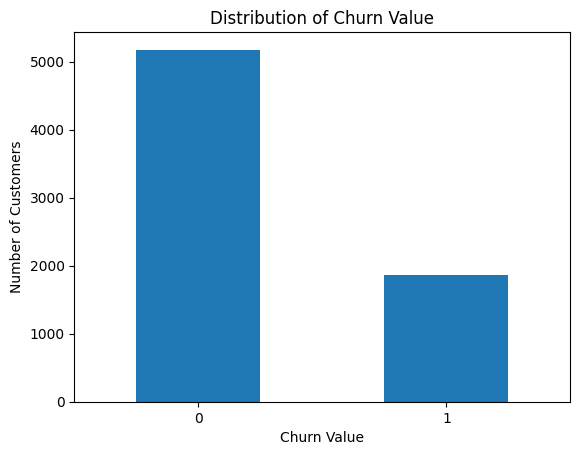

In [120]:
import matplotlib.pyplot as plt

churn_count.plot(kind="bar")

plt.title("Distribution of Churn Value")
plt.xlabel("Churn Value")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Class Imbalance Findings

The target variable `Churn Value` is imbalanced:

- Non-churn (0): 73.46%
- Churn (1): 26.54%

The majority class is non-churn, while churn customers represent approximately
one quarter of the dataset.

Therefore, accuracy alone may not be sufficient for evaluating the predictive
model. Precision, Recall, F1-score and ROC-AUC should also be considered,
particularly for the churn class.

At this stage, no resampling technique is applied. During modeling, a
stratified train/test split will be used, and imbalance-handling techniques
such as class weighting or SMOTE may be evaluated if necessary.

# T013 — Data Quality Report

In [121]:
data_quality_report = pd.DataFrame({
    "Issue": [
        "Blank Values",
        "Incorrect Data Type",
        "Duplicate Records",
        "Duplicate CustomerID",
        "Outliers",
        "Class Imbalance",
        "Potential Data Leakage"
    ],

    "Feature": [
        "Total Charges",
        "Total Charges",
        "All columns",
        "CustomerID",
        "Numerical features",
        "Churn Value",
        "Churn Label / Churn Score / Churn Reason"
    ],

    "Finding": [
        "11 blank values",
        "Stored as object although conceptually numerical",
        "0 duplicated records",
        "0 duplicated CustomerID",
        "0 potential outliers detected using IQR",
        "0: 73.46%, 1: 26.54%",
        "Features contain or may contain information directly related to churn outcome"
    ],

    "Proposed Action": [
        "Handle blank values during data cleaning",
        "Convert to numeric after handling blanks",
        "No action required",
        "No action required",
        "No outlier treatment required",
        "Use stratified split and evaluate imbalance handling during modeling",
        "Exclude/review before model training to prevent leakage"
    ]
})

data_quality_report

,Issue,Feature,Finding,Proposed Action
0,Blank Values,Total Charges,11 blank values,Handle blank values during data cleaning
1,Incorrect Data Type,Total Charges,Stored as object although conceptually numerical,Convert to numeric after handling blanks
2,Duplicate Records,All columns,0 duplicated records,No action required
3,Duplicate CustomerID,CustomerID,0 duplicated CustomerID,No action required
4,Outliers,Numerical features,0 potential outliers detected using IQR,No outlier treatment required
5,Class Imbalance,Churn Value,"0: 73.46%, 1: 26.54%",Use stratified split and evaluate imbalance ha...
6,Potential Data Leakage,Churn Label / Churn Score / Churn Reason,Features contain or may contain information di...,Exclude/review before model training to preven...
